In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from multitask_sparse_parity import MultitaskSparseParityDataset, MultitaskSparseParityModel
from storer import Storer
from train_mtsp_model_uniform_task_distribution_modal import TrainConfig
import seaborn as sns
import torch
import einops

/Users/jack/Desktop/Jack/tests/mats-9/scaling/spd-multitasksparseparity/spd/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# d_mlp = 16
storer = Storer("/modal_volume/mtsp_results/metrics/")
config = TrainConfig(seed=0)

storer.add_datestamp_prefix()
storer.add_prefix(f"train_mtsp_model_uniform_task_distribution/v10/{config.cache_key()}")

torch.manual_seed(config.seed)
model = MultitaskSparseParityModel(
    d_mlp=config.d_mlp, n_control_bits=config.n_control_bits, n_task_bits=config.n_task_bits
)
dataset = MultitaskSparseParityDataset(
    n_control_bits=config.n_control_bits,
    n_task_bits=config.n_task_bits,
    n_xored_bits=config.n_xored_bits,
    task_distribution_decay_rate=config.task_distribution_decay_rate,
    batch_sz=config.batch_sz,
    size=config.steps,
)
storer.add_prefix(f"model/{config.steps}")
key = "model"
assert storer.exists(key), (d_mlp, storer)
model.load_state_dict(storer.read(key))
losses_by_step_and_task: np.ndarray = storer.read("losses_by_step_and_task")

torch.manual_seed(0)
task_ids, task_bits, parity = dataset.get_batch(batch_sz=1024)
logits = model((task_ids, task_bits, ()))
val_loss = F.cross_entropy(logits, parity)
print(val_loss)

tensor(1.6098e-05, grad_fn=<NllLossBackward0>)


In [3]:
l2_synth = model.l2.weight.data[0] - model.l2.weight.data[1]

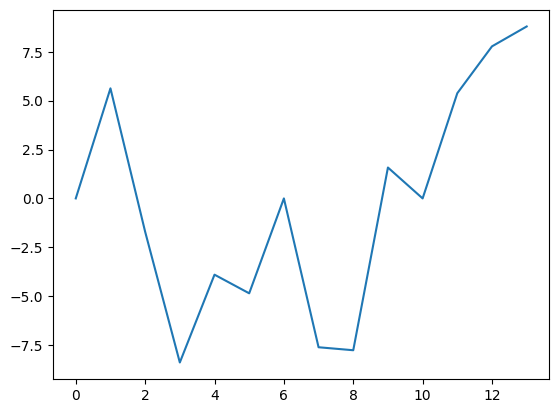

In [4]:
plt.plot(l2_synth)

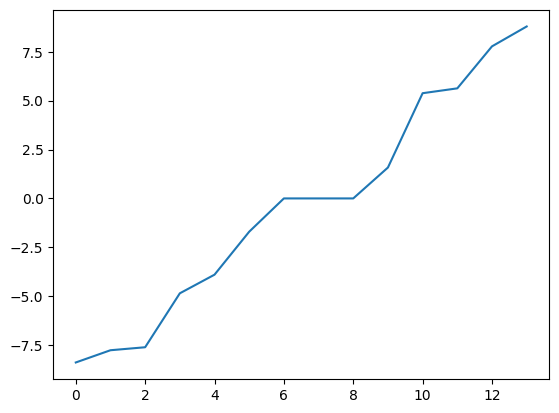

In [5]:
plt.plot(l2_synth[l2_synth.sort().indices])

In [6]:
dataset.selected_bits_by_task + 1

tensor([[24,  8, 10,  2]])

In [7]:
# sns.heatmap(model.l1.weight.data[l2_synth.sort().indices])

<Axes: >

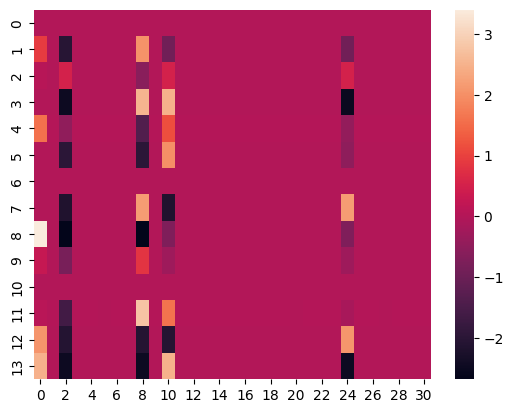

In [8]:
sns.heatmap(model.l1.weight.data)

<Axes: >

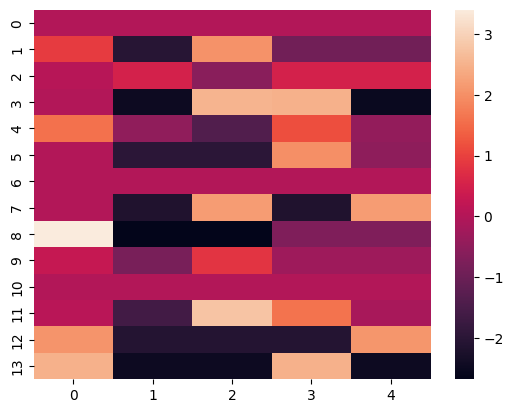

In [9]:
sns.heatmap(
    model.l1.weight.data[
        :, torch.cat([torch.tensor([0]), dataset.selected_bits_by_task[0].sort().values + 1])
    ]
)

In [10]:
l1_for_task0 = model.l1.weight.data[
    :, torch.cat([torch.tensor([0]), dataset.selected_bits_by_task[0].sort().values + 1])
]

In [11]:
F.relu(input=(torch.tensor([1, 0, 0, 0, 0]).float() @ l1_for_task0.T)) @ l2_synth

tensor(11.1606)

In [71]:
task_ids = torch.tensor(0).repeat(2**config.n_xored_bits)
bits = (
    torch.floor(
        torch.arange(2**config.n_xored_bits).unsqueeze(1) / (2 ** torch.arange(config.n_xored_bits))
    )
    % 2
).long()
x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), bits], dim=1).float()
x2 = x1 @ l1_for_task0.T
x3 = F.relu(x2)
x4 = x3 @ l2_synth
x4

tensor([ 11.1606, -10.9241, -10.4835,  11.8833, -10.3314,  11.5204,  11.1068,
        -10.2371, -10.4390,  11.6536,  10.4946, -11.4183,  12.8747,  -9.8652,
        -11.3910,  11.1564])

In [13]:
F.relu(l1_for_task0[:, 0]) @ l2_synth

tensor(11.1606)

In [ ]:
(torch.cat(list([x.reshape(-1) for x in iter(model.parameters())])) ** 0.9) ** (1 / 0.9)

tensor([3.1242e-19, 1.1338e-19,        nan, 1.1334e-19, 3.1242e-19, 9.6696e-23,
        3.1242e-19, 5.1804e-18,        nan,        nan,        nan,        nan,
        1.1339e-19,        nan,        nan,        nan,        nan, 3.1242e-19,
        9.7059e-23, 1.1347e-19, 1.0460e-17, 1.1345e-19, 3.1242e-19,        nan,
               nan, 3.1242e-19, 1.1331e-19, 3.1242e-19, 1.0460e-17,        nan,
               nan, 9.0923e-01, 3.2222e-04,        nan, 3.2624e-04, 3.2374e-04,
        3.2220e-04, 3.2561e-04, 3.2486e-04, 2.0413e+00, 3.2734e-04,        nan,
        3.2494e-04, 3.2334e-04, 3.2181e-04, 3.2185e-04, 3.2417e-04, 3.2536e-04,
        3.2442e-04, 3.2477e-04, 3.2525e-04, 3.2611e-04, 3.2405e-04, 3.2473e-04,
        3.2240e-04,        nan, 3.2286e-04, 3.2307e-04, 3.2563e-04, 3.2388e-04,
        3.2580e-04, 3.2474e-04, 7.0912e-02, 5.5994e-08, 5.1666e-01, 3.2672e-08,
               nan, 2.4951e-08, 2.3204e-08,        nan,        nan, 7.2518e-08,
        5.1667e-01, 2.4936e-08, 1.6666e-

In [15]:
def get_param_norm(model, p):
    total = sum(param.norm(p) ** p for param in model.parameters())
    return total ** (1 / p)

In [16]:
get_param_norm(model, p=0.9)

tensor(230.1122, grad_fn=<PowBackward0>)

In [ ]:
(torch.abs((torch.tensor(0.5))) ** 0.000001) ** (1 / 0.000001)

tensor(0.4891)

In [18]:
0.5**0.1

0.9330329915368074

In [19]:
torch.cat(list([x.reshape(-1) for x in iter(model.parameters())]))

tensor([ 3.1242e-19,  1.1338e-19, -3.1241e-19,  1.1334e-19,  3.1242e-19,
         9.6697e-23,  3.1242e-19,  5.1804e-18, -3.1242e-19, -3.1241e-19,
        -2.4637e-18, -1.1322e-19,  1.1339e-19, -2.4637e-18, -9.7699e-23,
        -9.6319e-23, -1.0460e-17,  3.1242e-19,  9.7059e-23,  1.1347e-19,
         1.0460e-17,  1.1345e-19,  3.1242e-19, -3.1241e-19, -1.1321e-19,
         3.1242e-19,  1.1331e-19,  3.1242e-19,  1.0460e-17, -3.1241e-19,
        -1.1327e-19,  9.0923e-01,  3.2222e-04, -2.0420e+00,  3.2624e-04,
         3.2374e-04,  3.2220e-04,  3.2561e-04,  3.2486e-04,  2.0413e+00,
         3.2734e-04, -9.1311e-01,  3.2494e-04,  3.2334e-04,  3.2181e-04,
         3.2185e-04,  3.2417e-04,  3.2536e-04,  3.2442e-04,  3.2477e-04,
         3.2525e-04,  3.2611e-04,  3.2405e-04,  3.2473e-04,  3.2240e-04,
        -9.1313e-01,  3.2286e-04,  3.2307e-04,  3.2563e-04,  3.2388e-04,
         3.2580e-04,  3.2474e-04,  7.0912e-02,  5.5994e-08,  5.1666e-01,
         3.2672e-08, -1.1604e-09,  2.4951e-08,  2.3

<Axes: >

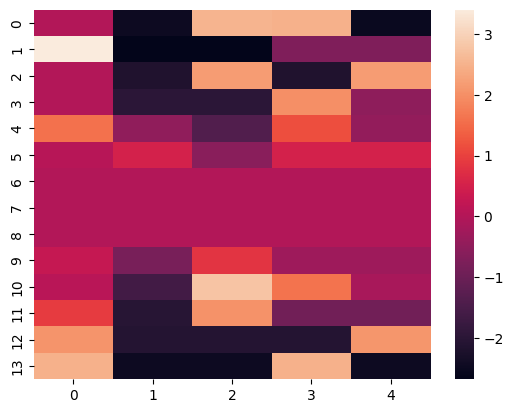

In [20]:
sns.heatmap(l1_for_task0[l2_synth.sort().indices])

In [49]:
# neuron_mask = torch.ones(model.l1.out_features).bool()
neuron_mask = ~(model.l1.weight.data.abs().amax(-1) < 1e-14)
assert (l2_synth[~neuron_mask] < 1e-14).all()
(~neuron_mask).sum()

tensor(3)

<Axes: >

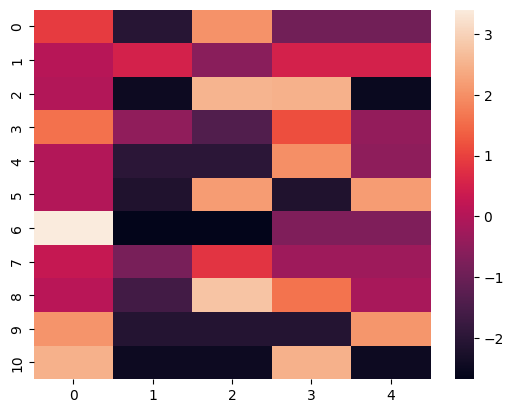

In [50]:
sns.heatmap(l1_for_task0[neuron_mask])

<Axes: >

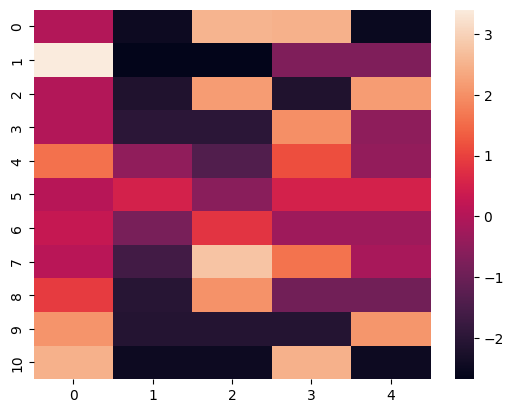

In [57]:
sns.heatmap(l1_for_task0[neuron_mask][l2_synth[neuron_mask].sort().indices])

In [78]:
task_ids = torch.tensor(0).repeat(2**config.n_xored_bits)
bits = (
    torch.floor(
        torch.arange(2**config.n_xored_bits).unsqueeze(1) / (2 ** torch.arange(config.n_xored_bits))
    )
    % 2
).long()
x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), bits], dim=1).float()
x2 = x1 @ l1_for_task0[neuron_mask].T
x3 = F.relu(x2)
x4 = x3 @ l2_synth[neuron_mask]
x4

tensor([ 11.1606, -10.9241, -10.4835,  11.8833, -10.3314,  11.5204,  11.1068,
        -10.2371, -10.4390,  11.6536,  10.4946, -11.4183,  12.8747,  -9.8652,
        -11.3910,  11.1564])

In [89]:
bits

tensor([[0, 0, 0, 0],
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [1, 1, 0, 0],
        [0, 0, 1, 0],
        [1, 0, 1, 0],
        [0, 1, 1, 0],
        [1, 1, 1, 0],
        [0, 0, 0, 1],
        [1, 0, 0, 1],
        [0, 1, 0, 1],
        [1, 1, 0, 1],
        [0, 0, 1, 1],
        [1, 0, 1, 1],
        [0, 1, 1, 1],
        [1, 1, 1, 1]])

<Axes: >

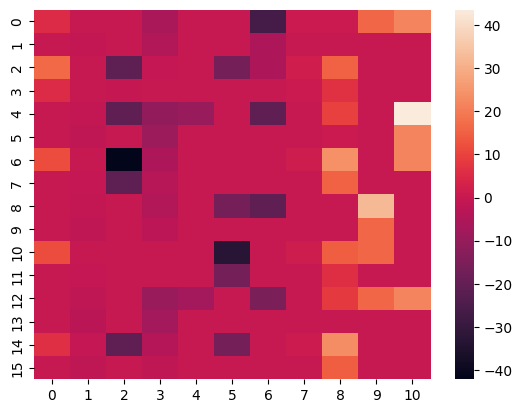

In [88]:
sns.heatmap(x3 * l2_synth[neuron_mask])

()

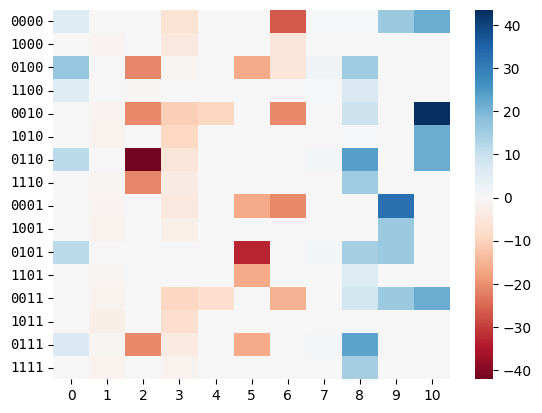

In [146]:
bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
ax = sns.heatmap(x3 * l2_synth[neuron_mask], cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

()

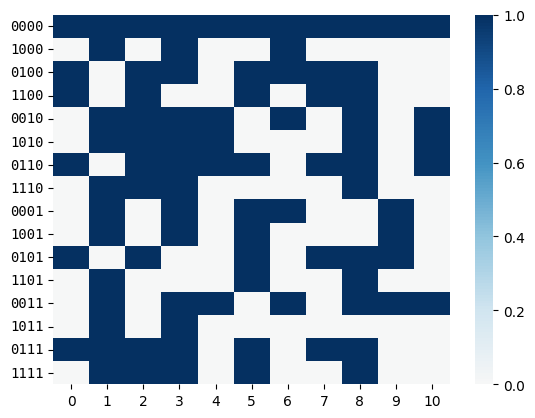

In [195]:
ax = sns.heatmap(x2 >= 0, cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

In [235]:
l2_synth[neuron_mask]

tensor([ 5.6304, -1.7026, -8.3918, -3.9007, -4.8538, -7.6129, -7.7657,  1.5806,
         5.3819,  7.7784,  8.7952])

In [229]:
for x in (l1_for_task0[neuron_mask][:, 0]/3.40333 * 16 * 6):
    print(f"{x:.6f}", end=' ')

25.647194 2.000273 0.000034 44.961014 0.000002 0.000010 96.000244 8.004104 2.472566 58.408058 69.858246 

<Axes: >

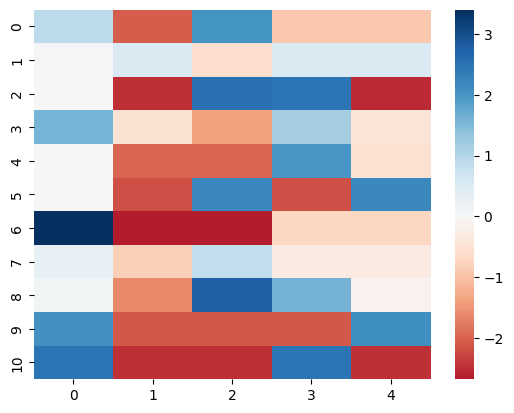

In [ ]:
sns.heatmap(l1_for_task0[neuron_mask], cmap="RdBu", center=0)

<Axes: >

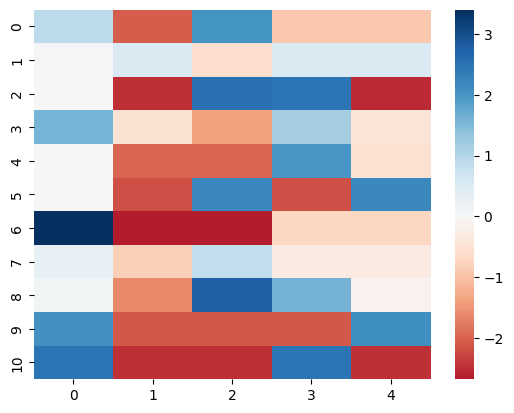

In [ ]:
sns.heatmap(l1_for_task0[neuron_mask], cmap="RdBu", center=0)

()

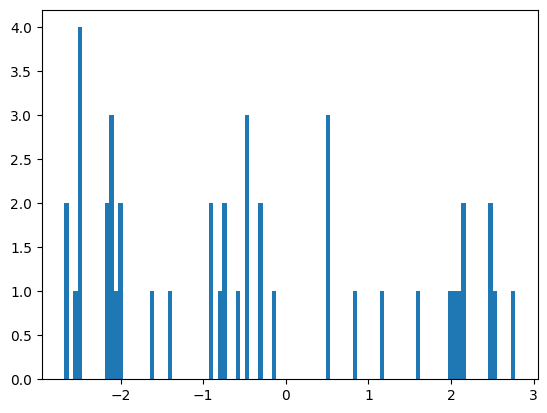

In [185]:
plt.hist(l1_for_task0[neuron_mask][:, 1:].reshape(-1), bins=100)
()

In [150]:
(x3 * l2_synth[neuron_mask])

tensor([[ 5.1193e+00, -1.2074e-01, -1.0088e-05, -6.2174e+00, -2.8668e-07,
         -2.7321e-06, -2.6429e+01,  4.4849e-01,  4.7176e-01,  1.6106e+01,
          2.1782e+01],
        [ 0.0000e+00, -1.0004e+00, -0.0000e+00, -4.3182e+00, -0.0000e+00,
         -0.0000e+00, -5.6055e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00],
        [ 1.6613e+01, -0.0000e+00, -2.1292e+01, -8.4870e-01, -0.0000e+00,
         -1.6516e+01, -5.6055e+00,  1.7488e+00,  1.5416e+01,  0.0000e+00,
          0.0000e+00],
        [ 5.1157e+00, -0.0000e+00, -4.1608e-01, -0.0000e+00, -0.0000e+00,
         -1.9966e-05, -0.0000e+00,  4.4849e-01,  6.7352e+00,  0.0000e+00,
          0.0000e+00],
        [ 0.0000e+00, -1.0004e+00, -2.0875e+01, -1.0744e+01, -9.6453e+00,
         -0.0000e+00, -2.0824e+01,  0.0000e+00,  9.1474e+00,  0.0000e+00,
          4.3611e+01],
        [ 0.0000e+00, -1.8801e+00, -1.2005e-05, -8.8453e+00, -0.0000e+00,
         -0.0000e+00, -0.0000e+00,  0.0000e+00,  4.6647e-01,  0.0000e+0

()

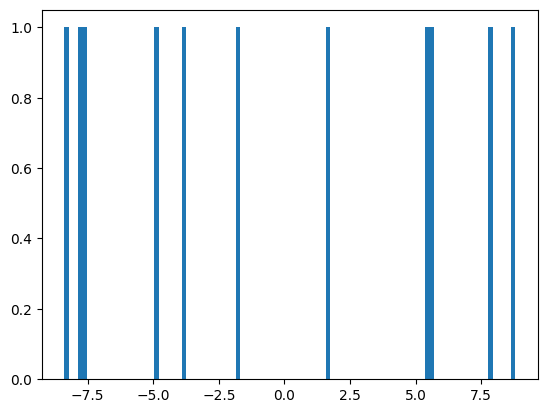

In [176]:
# plt.hist((l2_synth[neuron_mask].reshape(-1) - 1.6)/4.1, bins=100)
plt.hist((l2_synth[neuron_mask].reshape(-1)), bins=100)
()

In [147]:
(x3 * l2_synth[neuron_mask]).sum(-1)

tensor([ 11.1606, -10.9241, -10.4835,  11.8833, -10.3314,  11.5204,  11.1068,
        -10.2371, -10.4390,  11.6536,  10.4946, -11.4183,  12.8747,  -9.8652,
        -11.3910,  11.1564])

In [ ]:
logits = (x3 * l2_synth[neuron_mask]).sum(-1)
target = bits.sum(-1) % 2
F.binary_cross_entropy_with_logits(
    -logits, target.float()
)  # .float() as binary_cross_entropy_with_logits supports soft targets

tensor(1.9819e-05)

<Axes: >

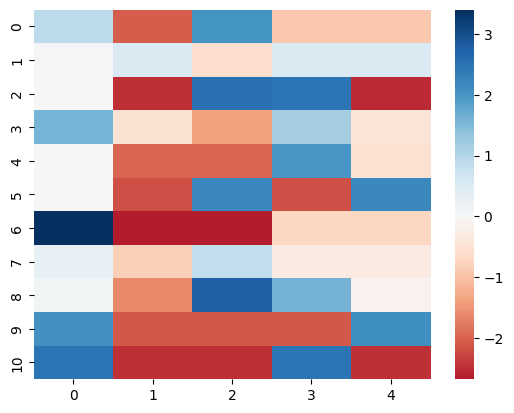

In [109]:
sns.heatmap(l1_for_task0[neuron_mask], cmap="RdBu", center=0)

In [118]:
l1_for_task0[neuron_mask][:, 1:].shape

torch.Size([11, 4])

(array([2., 0., 1., 4., 0., 0., 0., 0., 0., 2., 3., 1., 2., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 2., 0.,
        1., 2., 0., 0., 1., 0., 3., 0., 0., 2., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 3., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        1., 1., 1., 2., 0., 0., 0., 0., 0., 2., 1., 0., 0., 0., 1.]),
 array([-2.68151212, -2.62692928, -2.57234645, -2.51776361, -2.46318078,
        -2.40859795, -2.35401511, -2.29943228, -2.24484944, -2.19026661,
        -2.13568377, -2.08110094, -2.02651811, -1.97193527, -1.91735244,
        -1.8627696 , -1.80818677, -1.75360394, -1.6990211 , -1.64443827,
        -1.58985543, -1.5352726 , -1.48068976, -1.42610693, -1.3715241 ,
        -1.31694126, -1.26235843, -1.20777559, -1.15319276, -1.09860992,
        -1.04402709, -0.98944426, -0.93486142, -0.88027859, -0.82569575,
        -0.77111292, -0.71653008, -0.66

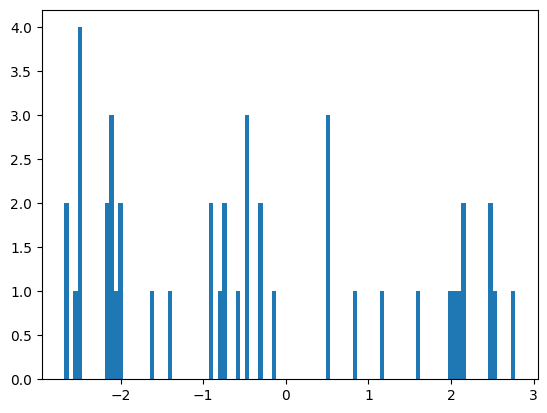

In [119]:
plt.hist(l1_for_task0[neuron_mask][:, 1:].reshape(-1), bins=100)

In [100]:
l1_for_task0[neuron_mask][10]

tensor([ 2.4766, -2.4822, -2.4814,  2.4819, -2.4830])

tensor([ 2.8610e-06,  9.5367e-07,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         9.5367e-07,  0.0000e+00,  9.5367e-07,  0.0000e+00,  9.5367e-07,
        -9.5367e-07,  0.0000e+00,  3.8147e-06,  0.0000e+00,  9.5367e-07,
        -9.5367e-07])

In [65]:
l1_for_task0[neuron_mask].shape

torch.Size([11, 5])

In [56]:
# plt.plot(l2_synth[neuron_mask].sort().values.abs())

14

In [22]:
torch.tensor(2, dtype=torch.float).norm(2)

tensor(2.)

<Axes: >

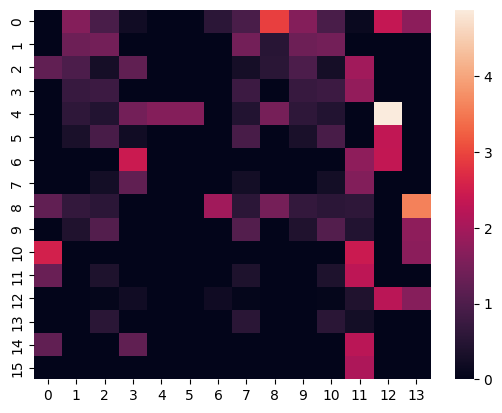

In [13]:
sns.heatmap(F.relu(input=x2))

<Axes: >

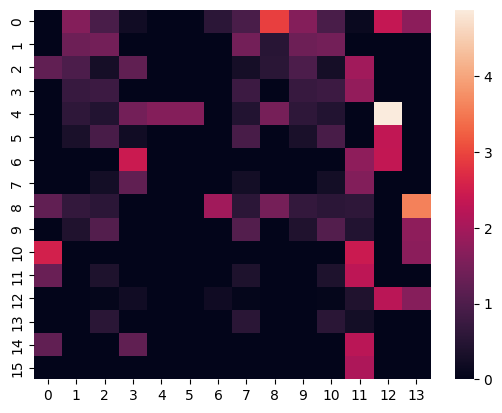

In [14]:
sns.heatmap(F.relu(input=x2))

In [22]:
a = F.relu(input=x2) @ ((l2_synth > 0) * 2 - 1).float()
a

tensor([ 0.9016, -2.0912,  0.0547,  0.9204, -1.4292, -0.0093,  1.6414, -0.4008,
        -0.8184, -0.1702,  1.6079, -0.2051,  3.7027, -1.3897, -0.2228,  2.0841])

In [23]:
(bits.sum(-1) % 2 == 0) == (a > 0)

tensor([ True,  True, False,  True,  True, False,  True,  True,  True, False,
         True,  True,  True,  True,  True,  True])

In [24]:
bits

tensor([[0, 0, 0, 0],
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [1, 1, 0, 0],
        [0, 0, 1, 0],
        [1, 0, 1, 0],
        [0, 1, 1, 0],
        [1, 1, 1, 0],
        [0, 0, 0, 1],
        [1, 0, 0, 1],
        [0, 1, 0, 1],
        [1, 1, 0, 1],
        [0, 0, 1, 1],
        [1, 0, 1, 1],
        [0, 1, 1, 1],
        [1, 1, 1, 1]])

<Axes: >

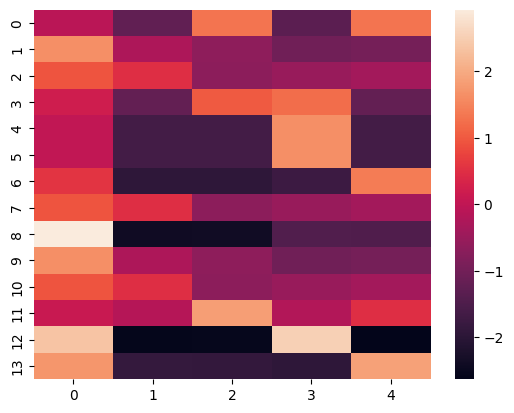

In [25]:
sns.heatmap(l1_for_task0)

<Axes: >

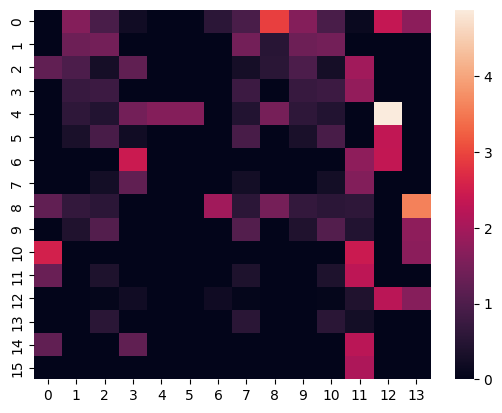

In [26]:
sns.heatmap(F.relu(input=x2))

<Axes: >

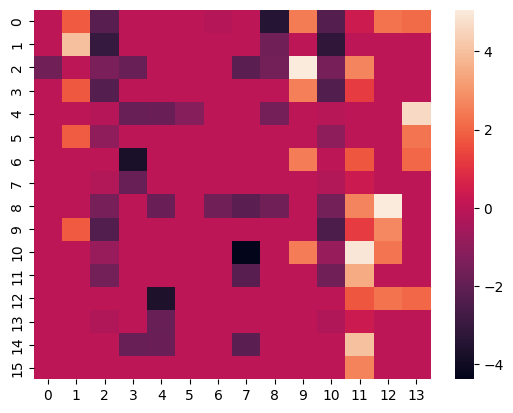

In [ ]:
# sns.heatmap((F.relu(input=x2) * l2_synth))
sns.heatmap((F.relu(input=x2) * ((l2_synth > 0) * 2 - 1)))

In [123]:
x4

tensor([ 17.6185, -11.8157, -15.4918,  15.6542, -13.2808,  19.9999,  11.8941,
        -15.3787, -15.1771,  15.5628,  18.5022, -15.0493,  11.9677, -15.2677,
        -24.1513,  13.5810])

In [ ]:
model.l1.weight[torch,]

IndexError: index 33 is out of bounds for dimension 0 with size 31

In [47]:
l2_synth @ model.l1.weight.data[:, 0]

tensor(18.6701)

In [48]:
x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), task_bits], dim=1).float()
x2 = model.l1(x1)
x3 = F.relu(x2)
x4 = model.l2(x3)
x4

x1 = x1.detach()
x2 = x2.detach()
x3 = x3.detach()
x4 = x4.detach()

In [15]:
batch_sz = 1
task_ids = torch.tensor([0])
bits = torch.tensor([0, 0, 0, 0])
task_bits = torch.zeros((batch_sz, config.n_task_bits), dtype=torch.long)
task_bits[0, dataset.selected_bits_by_task[0]] = bits

In [49]:
task_id = 0
batch_sz = 2**config.n_xored_bits
task_ids = torch.tensor([task_id]).repeat(batch_sz)
# bits = torch.tensor([0,0,0,0])
bits = (
    torch.floor(
        torch.arange(2**config.n_xored_bits).unsqueeze(1) / (2 ** torch.arange(config.n_xored_bits))
    )
    % 2
).long()
task_bits = torch.zeros((batch_sz, config.n_task_bits), dtype=torch.long)
task_bits[:, dataset.selected_bits_by_task[task_id]] = bits

In [50]:
# l2_synth = model.l2.weight.data[0] - model.l2.weight.data[1]

x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), task_bits], dim=1).float()
x2 = model.l1(x1)
x3 = F.relu(x2)
x4 = x3 @ l2_synth

x1 = x1.detach()
x2 = x2.detach()
x3 = x3.detach()
x4 = x4.detach()

x4

tensor([ 17.6185, -15.1771, -15.4918,  18.5022, -13.2808,  11.9677,  11.8941,
        -24.1513, -11.8157,  15.5628,  15.6542, -15.0493,  19.9999, -15.2677,
        -15.3787,  13.5810])

In [57]:
l2_synth @ F.relu(model.l1.weight.data[:, 0])

tensor(17.6185)

<Axes: >

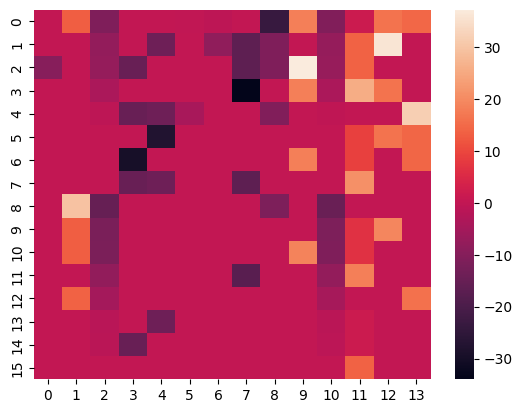

In [65]:
sns.heatmap((x3 * l2_synth))

In [139]:
dataset.selected_bits_by_task[0]

tensor([ 7, 17, 21, 16])

In [140]:
model.l1.weight.data[[17]].shape

torch.Size([1, 40])

<Axes: >

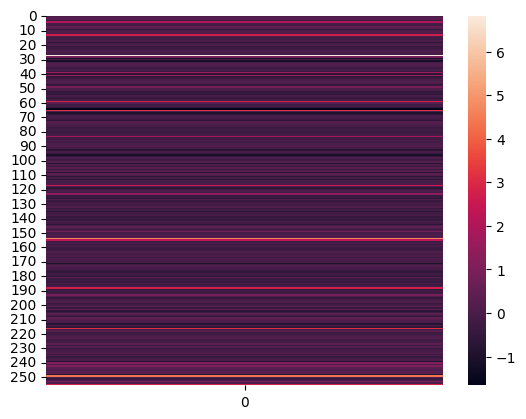

In [141]:
sns.heatmap(model.l1.weight.data[:, [0]])


<Axes: >

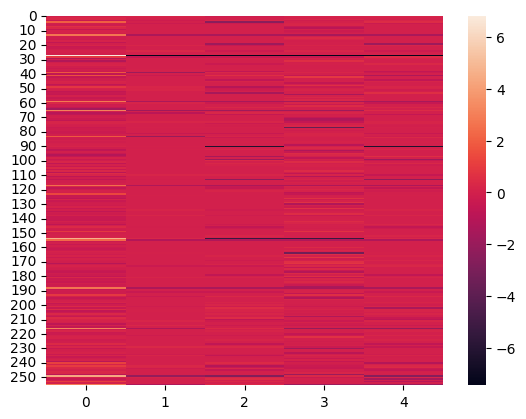

In [ ]:
sns.heatmap(
    model.l1.weight.data[:, torch.cat([torch.tensor([0]), dataset.selected_bits_by_task[0] + 10])]
)

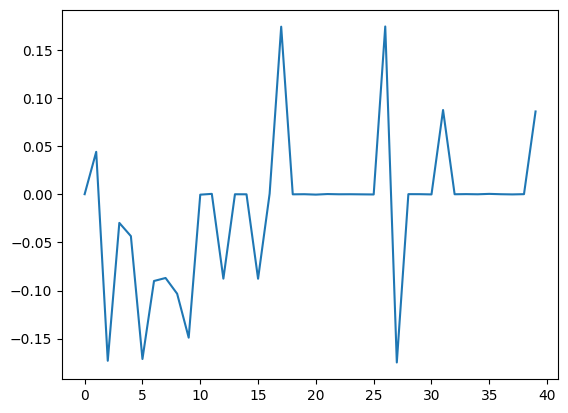

In [143]:
plt.plot(model.l1.weight.data[0])

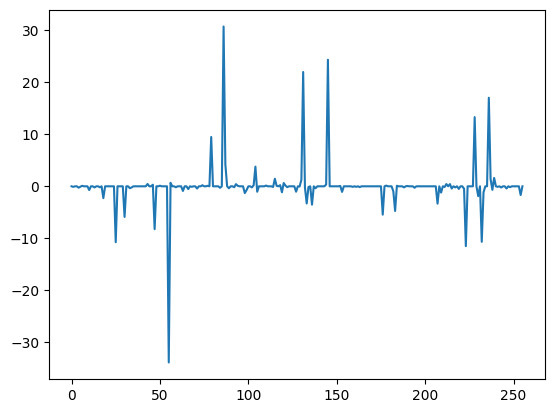

In [146]:
plt.plot((x3 * l2_synth)[0])
# plt.plot((x3 * l2_synth)[1])
# plt.plot((x3 * l2_synth)[2])
# plt.plot((x3 * l2_synth)[3])
# plt.plot((x3 * l2_synth)[14])
# plt.plot((x3 * l2_synth)[15])

In [119]:
(x3 * l2_synth)[15].sum()

tensor(9.2621)

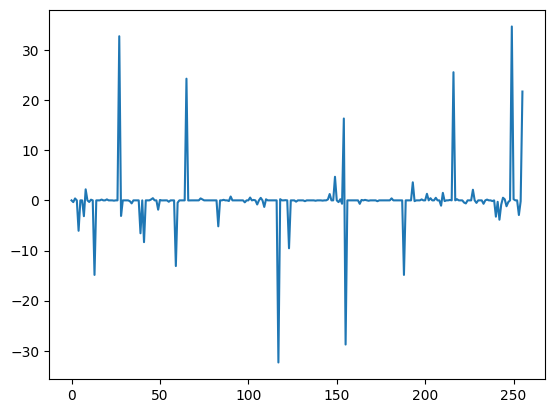

In [24]:
plt.plot((x3 * l2_synth)[0])

In [15]:
l2_synth.shape

torch.Size([256])

In [16]:
(x3 @ model.l2.weight.data.T)

tensor([[ 4.2240, -4.2121],
        [-5.3781,  5.3898],
        [-4.9356,  4.9407],
        [ 4.6369, -4.6342],
        [-4.9352,  4.9405],
        [ 4.7689, -4.7663],
        [ 6.7091, -6.7092],
        [-4.5671,  4.5673],
        [-5.2173,  5.2297],
        [ 4.4800, -4.4702],
        [ 4.6336, -4.6305],
        [-5.9108,  5.9139],
        [ 5.7992, -5.7958],
        [-4.2125,  4.2157],
        [-4.5332,  4.5332],
        [ 4.6310, -4.6311]])

In [17]:
(x3 @ model.l2.weight.data.T)

tensor([[ 4.2240, -4.2121],
        [-5.3781,  5.3898],
        [-4.9356,  4.9407],
        [ 4.6369, -4.6342],
        [-4.9352,  4.9405],
        [ 4.7689, -4.7663],
        [ 6.7091, -6.7092],
        [-4.5671,  4.5673],
        [-5.2173,  5.2297],
        [ 4.4800, -4.4702],
        [ 4.6336, -4.6305],
        [-5.9108,  5.9139],
        [ 5.7992, -5.7958],
        [-4.2125,  4.2157],
        [-4.5332,  4.5332],
        [ 4.6310, -4.6311]])

In [ ]:
einops.einsum(model.l2.weight.data, x3, 'two '

torch.Size([2, 256])

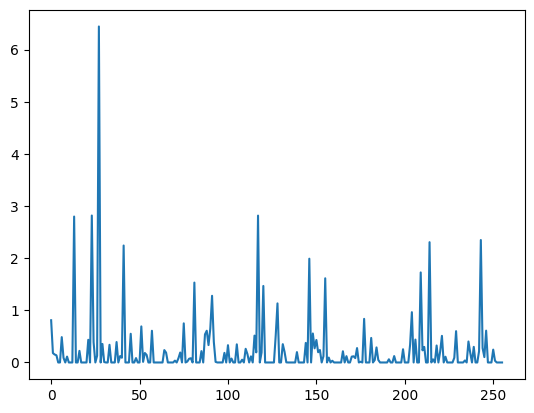

In [21]:
plt.plot(x3[0])

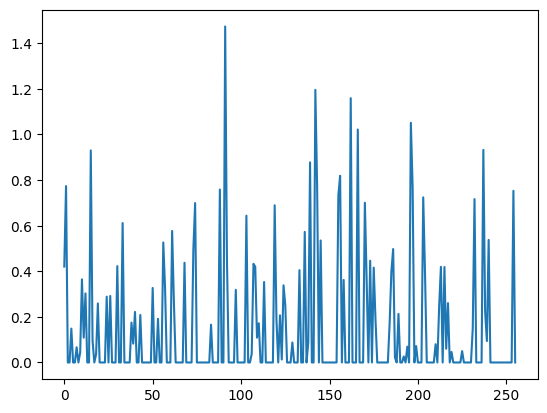

In [121]:
plt.plot(x3[0].detach())

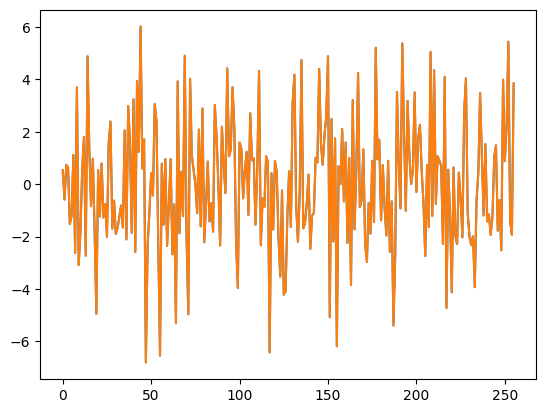

In [20]:
plt.plot(model.l2.weight.data[0])
plt.plot(-model.l2.weight.data[1])

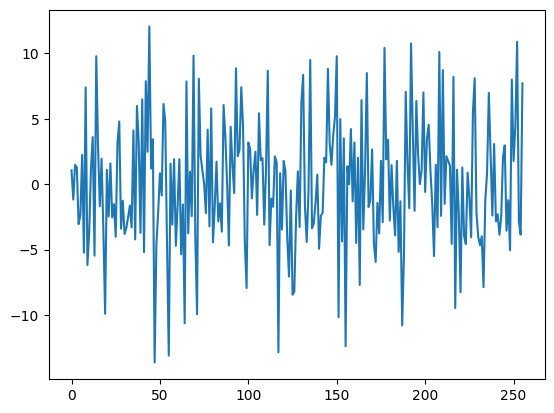

In [19]:
plt.plot(model.l2.weight.data[0] - model.l2.weight.data[1])

In [61]:
torch.randint(2, (1, config.n_xored_bits))

tensor([[1, 1, 1, 0]])

In [22]:
# plt.plot((model.l2.weight.data[0] - model.l2.weight.data[1]))
# plt.plot(model.l1.bias.data)

<Axes: >

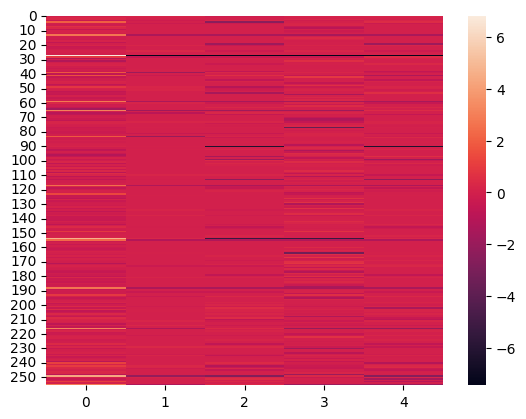

In [23]:
sns.heatmap(model.l1.weight.data[:, [0, 10 + 7, 10 + 17, 10 + 21, 10 + 16]])

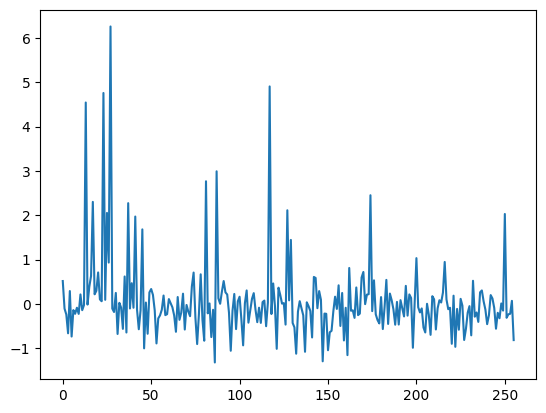

In [37]:
plt.plot(model.l1.weight.data[:, 0])

<Axes: >

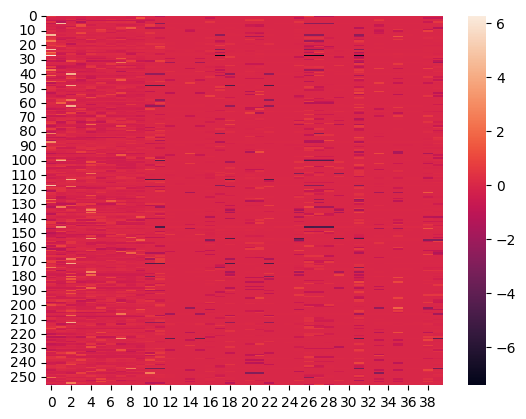

In [6]:
sns.heatmap(model.l1.weight.data)

In [7]:
(torch.arange(10, dtype=torch.float) + 1) ** -(0.4)

tensor([1.0000, 0.7579, 0.6444, 0.5743, 0.5253, 0.4884, 0.4592, 0.4353, 0.4152,
        0.3981])

In [ ]:
(torch.arange(10, dtype=torch.float) + 1) ** -(1 + 0.4)

tensor([1.0000, 0.3789, 0.2148, 0.1436, 0.1051, 0.0814, 0.0656, 0.0544, 0.0461,
        0.0398])